# Low-Level Discrete-Time LTI Gaussian Inference

This notebook studies a deliberately small parameter-inference problem in a state-space model. The model is simple enough that we can compute the marginal likelihood exactly, but rich enough to show how approximate likelihood evaluations can create a much harder geometry for posterior inference.

## Problem Setup And Research Goal

Our broader motivation is that parameter inference in dynamical systems is often hard not only because the latent state is unobserved, but because the likelihood available to the sampler is itself an approximation. In many realistic models, the exact marginal likelihood

$$
p(y_{1:T} \mid \theta)
$$

cannot be evaluated analytically, so we replace it with an estimate produced by a filter, particle method, simulator, or some other numerical scheme. That replacement can change the effective geometry seen by inference algorithms: the resulting log likelihood can become noisy, rough, biased, or locally unstable even when the underlying statistical model is smooth.

This notebook builds a first sandbox for studying that effect. We use a discrete-time linear time-invariant Gaussian state-space model with one unknown parameter $\alpha$. Because this model admits an exact Kalman-filter marginal likelihood, we can treat that as ground truth and then ask how particle-based approximations deform the profile likelihood, its gradient, and the posterior explored by NUTS.

Concretely, the notebook asks three questions:

1. What does the exact log marginal likelihood surface in $\alpha$ look like?
2. How do low-fidelity and high-fidelity particle filters deviate from that surface?
3. When we plug those likelihoods into HMC-style inference, what failure modes appear?

## Imports

In [1]:
import time

import arviz as az
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

from manual_discrete_time_inference import (
    kalman_filter_loglik,
    make_blackjax_logdensity,
    particle_filter_loglik,
    plot_lti_filter_comparison,
    plot_lti_synthetic_data,
    run_blackjax_nuts_1d,
    simulate_lti_discrete_gaussian,
)


## Synthetic Data

We work with a linear Gaussian state-space model with latent state $x_t \in \mathbb{R}^2$, scalar observation $y_t \in \mathbb{R}$, and control $u_t \in \mathbb{R}$. The unknown parameter is the scalar transition coefficient $\alpha$ appearing in the first state dimension.

The model is

$$
x_0 \sim \mathcal{N}(m_0, P_0),
$$

$$
x_t = A(\alpha) x_{t-1} + B u_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, Q),
$$

$$
y_t = H x_t + D u_t + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, R),
$$

with

$$
A(\alpha) = \begin{bmatrix} \alpha & 0 \\ 0 & 0.8 \end{bmatrix},
\qquad
H = \begin{bmatrix} 1 & 0 \end{bmatrix}.
$$

Everything except $\alpha$ is fixed. We simulate one dataset at a known ground-truth value $\alpha_\star = 0.4$, then pretend $\alpha$ is unknown and infer it from the observations.

This is a useful benchmark because the latent path is nontrivial, the observations are noisy, and the controls inject extra variation, but the exact marginal likelihood remains tractable.

In [ ]:
true_alpha = jnp.array(0.4)
obs_times = jnp.arange(0.0, 100.0, 1.0)
key = jr.PRNGKey(42)
key_ctrl, key_data = jr.split(key)
ctrl_values = jr.normal(key_ctrl, shape=(obs_times.shape[0], 1))

# Change these in one place so the profile and MCMC sections stay synchronized.
n_particles_lofi = 100
n_particles_hifi = 1000

# Keep the PF likelihood key visible here so profile and MCMC runs stay consistent.
pf_fixed_key = jr.PRNGKey(456)

process_noise_cov = 0.1 * jnp.eye(2)
# Larger observation noise (e.g. 0.5**2) makes NUTS + DPF easier to work with;
# Choosing 0.1**2 to make the problem challenging for NUTS + DPF with small particle count.
observation_noise_cov = jnp.array([[0.1**2]])
system_kwargs = {
    "Q": process_noise_cov,
    "R": observation_noise_cov,
}

times, states, observations = simulate_lti_discrete_gaussian(
    key_data,
    alpha=true_alpha,
    times=obs_times,
    ctrl_values=ctrl_values,
    system_kwargs=system_kwargs,
)
obs_values = observations[:, None]

print(f"Generated {len(times)} observations with true alpha = {float(true_alpha):.3f}")
print(f"Controls shape: {ctrl_values.shape}")
print(f"n_particles_lofi = {n_particles_lofi}, n_particles_hifi = {n_particles_hifi}")
print("PF fixed key:", pf_fixed_key)
print("Process noise covariance Q:")
print(process_noise_cov)
print("Observation noise covariance R:")
print(observation_noise_cov)


Generated 100 observations with true alpha = 0.400
Controls shape: (100, 1)
n_particles_lofi = 100, n_particles_hifi = 1000
PF fixed key: [  0 456]
Process noise covariance Q:
[[0.1 0. ]
 [0.  0.1]]
Observation noise covariance R:
[[0.01]]


(<Figure size 1000x700 with 3 Axes>,
 array([<Axes: title={'center': 'Synthetic latent states and observations'}, ylabel='state[0]'>,
        <Axes: ylabel='state[1]'>, <Axes: xlabel='time', ylabel='y'>],
       dtype=object))

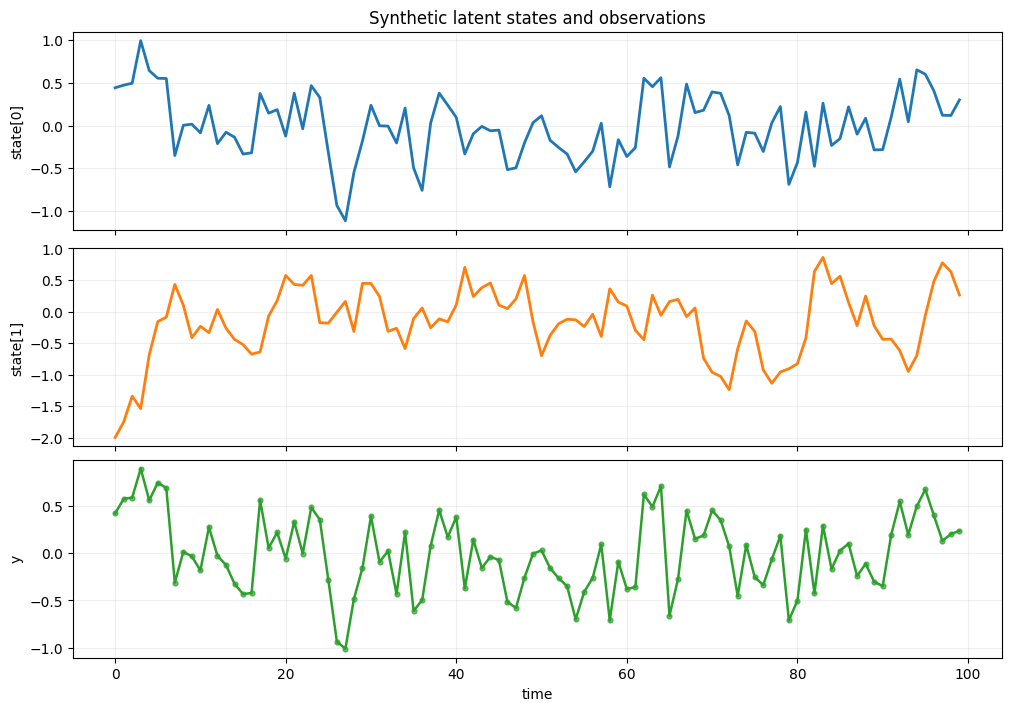

In [3]:
plot_lti_synthetic_data(times, states, observations)


## Exact And Approximate Marginal Likelihoods

For parameter inference we care about the marginal likelihood

$$
p(y_{1:T} \mid \alpha, u_{1:T}),
$$

obtained after integrating out the latent states $x_{0:T}$. In this linear Gaussian model, the Kalman filter gives that quantity exactly through the innovation decomposition:

$$
\log p(y_{1:T} \mid \alpha)
= \sum_{t=1}^T \log \mathcal{N}\bigl(y_t ; \mu_t^{\mathrm{pred}}(\alpha), S_t(\alpha)\bigr),
$$

where $\mu_t^{\mathrm{pred}}$ and $S_t$ are the one-step-ahead predictive mean and covariance from the filter.

That exact log marginal likelihood is our reference surface.

We also construct particle-filter estimates of the same quantity. These are unbiased on the likelihood scale under standard assumptions, but their log transforms are noisy and can be much rougher as functions of $\alpha$. That roughness is exactly what can destabilize gradient-based samplers.

Two comparison modes matter here:

- Fixed key over a parameter sweep: reuse the same random numbers for every value of $\alpha$. This often produces a smoother, more coupled profile across the grid.
- Independent-key sweeps: redraw the randomness across repeated sweeps to reveal estimator variability and show how much the approximate surface can move around.

The comparison below is therefore not just "exact versus approximate". It is really about how estimator fidelity and randomness control change the optimization and sampling landscape.

## Zoomed-In Profile Likelihood And Gradient Diagnostics

We now evaluate the log marginal likelihood over a grid of candidate $\alpha$ values. For each grid point we compute either:

- the exact Kalman-filter log marginal likelihood, or
- a particle-filter estimate using a chosen particle count.

We examine both the profile

$$
\ell(\alpha) = \log p(y_{1:T} \mid \alpha)
$$

and its derivative with respect to $\alpha$. In an ideal world, these curves are smooth enough for HMC or NUTS to navigate reliably. In practice, approximate likelihoods can create spurious local behaviour, unstable gradients, and seed-dependent artifacts.

The purpose of this section is to visualize those distortions directly before running any posterior sampler.

In [4]:
num_alpha_grid_points = 61
num_profile_sweeps = 50
alpha_grid = jnp.linspace(-0.6, 0.6, num_alpha_grid_points)
alpha_step = float(alpha_grid[1] - alpha_grid[0])
profile_keys = jr.split(jr.PRNGKey(123), num_profile_sweeps)

def marginal_loglik_at_alpha(alpha, *, filter_name, n_particles=None, key=None):
    if filter_name == "kf":
        loglik, _ = kalman_filter_loglik(alpha, obs_values=obs_values, ctrl_values=ctrl_values, system_kwargs=system_kwargs)
        return loglik
    return particle_filter_loglik(
        alpha,
        obs_values=obs_values,
        ctrl_values=ctrl_values,
        n_particles=n_particles,
        key=key,
        system_kwargs=system_kwargs,
    )

def fixed_key_profile_and_grad(key, *, n_particles):
    fn = lambda alpha: marginal_loglik_at_alpha(alpha, filter_name="pf", n_particles=n_particles, key=key)
    return jax.vmap(jax.value_and_grad(fn))(alpha_grid)

def independent_key_profile_and_grad(root_key):
    independent_keys = jr.split(root_key, num_alpha_grid_points)
    fn = lambda alpha, key: marginal_loglik_at_alpha(alpha, filter_name="pf", n_particles=n_particles_lofi, key=key)
    return jax.vmap(jax.value_and_grad(fn))(alpha_grid, independent_keys)

def deterministic_profile():
    profile, grad = jax.vmap(jax.value_and_grad(lambda alpha: marginal_loglik_at_alpha(alpha, filter_name="kf")))(alpha_grid)
    return {
        "profile": profile,
        "grad": grad,
        "numeric_grad": jnp.asarray(np.gradient(np.asarray(profile), alpha_step)),
    }

t0 = time.perf_counter()
independent_profiles, independent_grads = jax.vmap(independent_key_profile_and_grad)(profile_keys)
independent_profiles.block_until_ready()
independent_grads.block_until_ready()
profile_seconds = time.perf_counter() - t0

fixed_profile_lofi, fixed_grad_lofi = fixed_key_profile_and_grad(pf_fixed_key, n_particles=n_particles_lofi)
fixed_profile_hifi, fixed_grad_hifi = fixed_key_profile_and_grad(pf_fixed_key, n_particles=n_particles_hifi)
independent_numeric_grads = jnp.asarray(np.gradient(np.asarray(independent_profiles), alpha_step, axis=1))

profile_q05, profile_q50, profile_q95 = jnp.quantile(independent_profiles, jnp.array([0.05, 0.50, 0.95]), axis=0)
autodiff_grad_q05, autodiff_grad_q50, autodiff_grad_q95 = jnp.quantile(independent_grads, jnp.array([0.05, 0.50, 0.95]), axis=0)
_, numeric_grad_q50, _ = jnp.quantile(independent_numeric_grads, jnp.array([0.05, 0.50, 0.95]), axis=0)

comparison_curves = [
    {
        "label": f"DPF LoFi ({n_particles_lofi}) · fixed key over grid",
        "color": "C1",
        "linestyle": "-",
        "alpha": 0.95,
        "linewidth": 2.1,
        "profile": fixed_profile_lofi,
        "grad": fixed_grad_lofi,
    },
    {
        "label": f"DPF HiFi ({n_particles_hifi}) · fixed key over grid",
        "color": "C0",
        "linestyle": "-",
        "alpha": 0.95,
        "linewidth": 2.1,
        "profile": fixed_profile_hifi,
        "grad": fixed_grad_hifi,
    },
]

kf_result = deterministic_profile()
comparison_curves.append(
    {
        "label": "KF · deterministic sweep",
        "color": "C2",
        "linestyle": "-",
        "alpha": 0.95,
        "linewidth": 2.0,
        "profile": kf_result["profile"],
        "grad": kf_result["grad"],
    }
)
print(f"Computed DPF LoFi ({n_particles_lofi}) independent-key band with shape ({num_profile_sweeps}, {num_alpha_grid_points}) in {profile_seconds:.2f}s")


Computed DPF LoFi (100) independent-key band with shape (50, 61) in 3.59s


(<Figure size 1000x800 with 2 Axes>,
 array([<Axes: title={'center': 'Profile likelihood comparison'}, ylabel='log marginal likelihood'>,
        <Axes: title={'center': 'Gradient comparison'}, xlabel='alpha', ylabel='d/dalpha log likelihood'>],
       dtype=object))

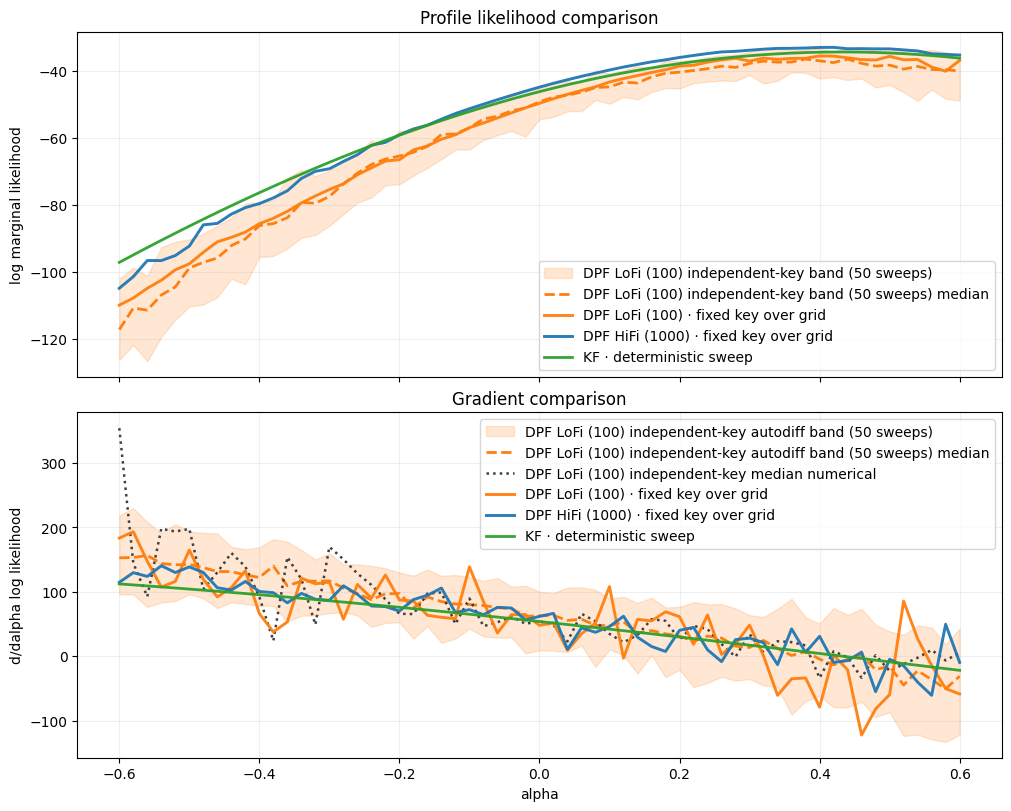

In [5]:
plot_lti_filter_comparison(
    parameter_grid=alpha_grid,
    profile_band_q05=profile_q05,
    profile_band_q50=profile_q50,
    profile_band_q95=profile_q95,
    grad_band_q05=autodiff_grad_q05,
    grad_band_q50=autodiff_grad_q50,
    grad_band_q95=autodiff_grad_q95,
    grad_numeric_q50=numeric_grad_q50,
    comparison_curves=comparison_curves,
    parameter_name="alpha",
    base_profile_label=f"DPF LoFi ({n_particles_lofi}) independent-key band ({num_profile_sweeps} sweeps)",
    base_grad_label=f"DPF LoFi ({n_particles_lofi}) independent-key autodiff band ({num_profile_sweeps} sweeps)",
    base_numeric_grad_label=f"DPF LoFi ({n_particles_lofi}) independent-key median numerical",
)


## Bayesian Inference With BlackJAX NUTS

Next we place the likelihood inside a Bayesian posterior for $\alpha$,

$$
p(\alpha \mid y_{1:T}) \propto p(y_{1:T} \mid \alpha) \, p(\alpha).
$$

The implementation below constructs log-density functions for the exact Kalman-filter likelihood together with low-fidelity and high-fidelity fixed-key particle-filter likelihoods. We then run BlackJAX NUTS on each target and compare posterior summaries, runtime, and effective sample size.

This is the real stress test of the notebook. If the approximate log likelihood is too rough, NUTS may adapt poorly, explore too slowly, or concentrate around a distorted posterior. Because we know the data-generating value and have an exact baseline, we can diagnose whether the issue comes from the posterior geometry induced by the estimator rather than from model misspecification.

Running KF ...


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)


KF: runtime=2.72s, mean=0.4405, std=0.0885, abs error=0.0405


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_6128/1956103344.py:104: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


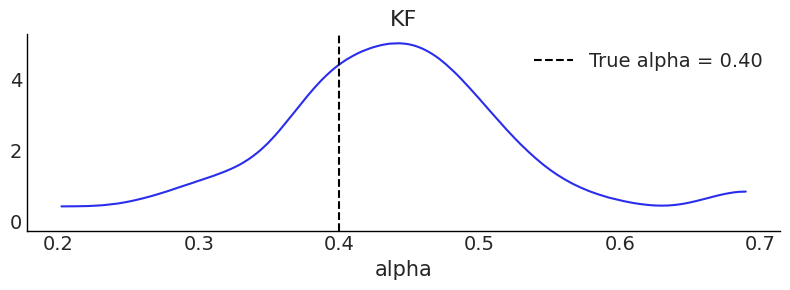

Running DPF HiFi (1000) · fixed key ...


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)


DPF HiFi (1000) · fixed key: runtime=27.75s, mean=0.3938, std=0.1063, abs error=0.0062


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_6128/1956103344.py:104: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


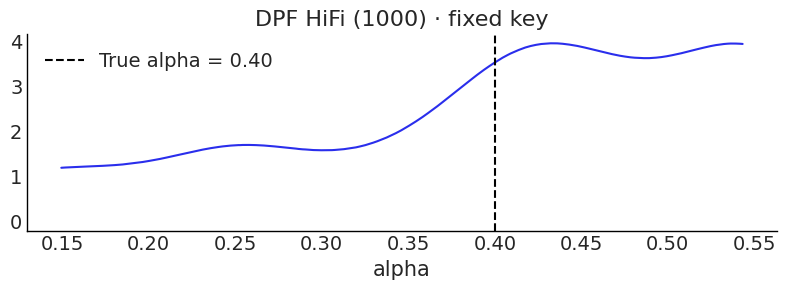

Running DPF LoFi (100) · fixed key ...


In [ ]:
az.style.use("arviz-white")

num_warmup = 100
num_samples = 100
true_alpha_value = float(true_alpha)

nuts_experiments = [
    {
        "name": "KF",
        "logdensity_fn": make_blackjax_logdensity(
            obs_values,
            ctrl_values=ctrl_values,
            filter_name="kf",
            system_kwargs=system_kwargs,
        ),
        "seed": 101,
        "color": "C2",
    },
    {
        "name": f"DPF HiFi ({n_particles_hifi}) · fixed key",
        "logdensity_fn": make_blackjax_logdensity(
            obs_values,
            ctrl_values=ctrl_values,
            filter_name="pf",
            n_particles=n_particles_hifi,
            fixed_key=pf_fixed_key,
            system_kwargs=system_kwargs,
        ),
        "seed": 103,
        "color": "C0",
    },
    {
        "name": f"DPF LoFi ({n_particles_lofi}) · fixed key",
        "logdensity_fn": make_blackjax_logdensity(
            obs_values,
            ctrl_values=ctrl_values,
            filter_name="pf",
            n_particles=n_particles_lofi,
            fixed_key=pf_fixed_key,
            system_kwargs=system_kwargs,
        ),
        "seed": 102,
        "color": "C1",
    },
]

nuts_results = []
nuts_inference_data = {}
nuts_samples_by_name = {}

for experiment in nuts_experiments:
    print(f"Running {experiment['name']} ...")
    t0 = time.perf_counter()
    run = run_blackjax_nuts_1d(
        experiment["logdensity_fn"],
        experiment["seed"],
        init_position=0.35,
        num_warmup=num_warmup,
        num_samples=num_samples,
    )
    elapsed_seconds = time.perf_counter() - t0

    posterior_alpha = np.asarray(run["samples"], dtype=float)
    inference_data = az.from_dict(posterior={"alpha": posterior_alpha[None, :]})
    summary = az.summary(inference_data, var_names=["alpha"], hdi_prob=0.95)
    alpha_summary = summary.loc["alpha"]

    result = {
        "name": experiment["name"],
        "runtime_seconds": float(elapsed_seconds),
        "posterior_mean": float(posterior_alpha.mean()),
        "posterior_std": float(posterior_alpha.std()),
        "hdi_2_5": float(alpha_summary["hdi_2.5%"]),
        "hdi_97_5": float(alpha_summary["hdi_97.5%"]),
        "ess_bulk": float(alpha_summary["ess_bulk"]),
        "r_hat": float(alpha_summary["r_hat"]),
        "color": experiment["color"],
    }
    result["abs_mean_error"] = abs(result["posterior_mean"] - true_alpha_value)
    result["rmse_to_truth"] = float(np.sqrt(np.mean((posterior_alpha - true_alpha_value) ** 2)))
    result["ess_bulk_per_second"] = result["ess_bulk"] / max(result["runtime_seconds"], 1e-9)

    nuts_results.append(result)
    nuts_inference_data[experiment["name"]] = inference_data
    nuts_samples_by_name[experiment["name"]] = posterior_alpha

    print(
        f"{experiment['name']}: runtime={elapsed_seconds:.2f}s, "
        f"mean={result['posterior_mean']:.4f}, std={result['posterior_std']:.4f}, "
        f"abs error={result['abs_mean_error']:.4f}"
    )

    fig, ax = plt.subplots(figsize=(8, 3))
    if np.nanstd(posterior_alpha) < 1e-10 or np.allclose(posterior_alpha, posterior_alpha[0]):
        ax.axvline(float(posterior_alpha.mean()), color=experiment["color"], linewidth=2.0, label="Posterior mass")
        ax.scatter([float(posterior_alpha.mean())], [0.0], color=experiment["color"], zorder=3)
        ax.set_ylabel("density")
    else:
        az.plot_kde(posterior_alpha, ax=ax)
    ax.axvline(true_alpha_value, color="black", linestyle="--", linewidth=1.5, label=f"True alpha = {true_alpha_value:.2f}")
    ax.set_title(experiment["name"])
    ax.set_xlabel("alpha")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

results_by_name = {result["name"]: result for result in nuts_results}
for result in nuts_results:
    print(result)


## Post-MCMC Comparison Plots

This block only reads the stored `nuts_results` and `nuts_samples_by_name` objects produced above. That makes it easy to rerun and tweak the visualization without rerunning the NUTS chains.

In [ ]:
if not nuts_results:
    raise RuntimeError("Run the NUTS cell above first so nuts_results is populated.")

names = [result["name"] for result in nuts_results]
posterior_means = np.array([result["posterior_mean"] for result in nuts_results], dtype=float)
abs_errors = np.array([result["abs_mean_error"] for result in nuts_results], dtype=float)
rmse_values = np.array([result["rmse_to_truth"] for result in nuts_results], dtype=float)
runtime_seconds = np.array([result["runtime_seconds"] for result in nuts_results], dtype=float)
ess_per_second = np.array([result["ess_bulk_per_second"] for result in nuts_results], dtype=float)
colors = [result["color"] for result in nuts_results]
posterior_samples = [np.asarray(nuts_samples_by_name[name], dtype=float) for name in names]
x = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5))
violin = ax.violinplot(
    posterior_samples,
    positions=x,
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
for body, color in zip(violin["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(0.35)

ax.scatter(x, posterior_means, s=80, c=colors, edgecolors="black", linewidths=0.8, zorder=3)
ax.axhline(true_alpha_value, color="black", linestyle="--", linewidth=1.5, label=f"True alpha = {true_alpha_value:.2f}")
for idx, error in enumerate(abs_errors):
    ax.text(
        idx,
        posterior_means[idx] + 0.03,
        f"|err|={error:.3f}\nrmse={rmse_values[idx]:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("Posterior alpha samples")
ax.set_title("NUTS posterior distributions across filter configurations")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, runtime_seconds, color=colors, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("Runtime (seconds)")
ax.set_title("NUTS cost across filter configurations")
for idx, bar in enumerate(bars):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{runtime_seconds[idx]:.1f}s\nESS/s={ess_per_second[idx]:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


## Summary

This notebook is meant to be read as a controlled experiment in likelihood-induced difficulty.

- The state-space model itself is simple and exactly tractable.
- The Kalman filter gives the true log marginal likelihood in $\alpha$.
- Particle filters let us inject controlled approximation error.
- NUTS then reveals how that error propagates into posterior inference.

That makes this example a clean starting point for studying tougher problems where no exact baseline exists. The broader research direction is to use toy models like this to identify failure modes, then design inference strategies that remain robust when approximate likelihoods are unavoidable.